## davis结果分析

In [1]:
import pandas as pd
import numpy as np
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve, precision_recall_curve, f1_score, accuracy_score, matthews_corrcoef
import matplotlib.pyplot as plt

In [2]:
# 定义函数：计算 AUC、AUPR 和分类指标
def calculate_metrics(file_path):
    # 读取文件
    data = pd.read_csv(file_path)
    y_true = data['classification_label']
    y_pred = data['predicted_binary_interaction']
    
    # 计算 AUC 和 AUPR
    auc = roc_auc_score(y_true, y_pred)
    aupr = average_precision_score(y_true, y_pred)
    
    # 初始化变量
    thresholds = np.linspace(0, 1, 1000)  # 在 [0, 1] 范围内生成 1000 个阈值
    best_f1 = 0
    best_threshold = 0
    best_metrics = {}
    
    # 遍历每个阈值，计算分类指标
    for threshold in thresholds:
        y_pred_binary = (y_pred >= threshold).astype(int)
        tp = np.sum((y_pred_binary == 1) & (y_true == 1))
        tn = np.sum((y_pred_binary == 0) & (y_true == 0))
        fp = np.sum((y_pred_binary == 1) & (y_true == 0))
        fn = np.sum((y_pred_binary == 0) & (y_true == 1))
        
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
        accuracy = (tp + tn) / (tp + tn + fp + fn)
        mcc = matthews_corrcoef(y_true, y_pred_binary) if (tp + fp) > 0 and (tp + fn) > 0 and (tn + fp) > 0 and (tn + fn) > 0 else 0
        
        # 更新最佳 F1 分数及对应的阈值和指标
        if f1 > best_f1:
            best_f1 = f1
            best_threshold = threshold
            best_metrics = {
                'accuracy': accuracy,
                'f1': f1,
                'precision': precision,
                'recall': recall,
                'mcc': mcc,
                'tp': tp,
                'tn': tn,
                'fp': fp,
                'fn': fn
            }
    
    # 计算 ROC 曲线和 PR 曲线
    fpr, tpr, roc_thresholds = roc_curve(y_true, y_pred)
    precision, recall, pr_thresholds = precision_recall_curve(y_true, y_pred)
    
    return {
        'auc': auc,
        'aupr': aupr,
        'best_threshold': best_threshold,
        'best_metrics': best_metrics,
        'roc_curve': (fpr, tpr),
        'pr_curve': (precision, recall)
    }

# 定义函数：绘制 ROC 和 PR 曲线
def plot_curves(results, output_path):
    plt.figure(figsize=(12, 6))
    
    # 绘制 ROC 曲线
    plt.subplot(1, 2, 1)
    for i, result in enumerate(results):
        fpr, tpr = result['roc_curve']
        plt.plot(fpr, tpr, label=f'File {i+1} (AUC={result["auc"]:.3f})')
    plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend()
    
    # 绘制 PR 曲线
    plt.subplot(1, 2, 2)
    for i, result in enumerate(results):
        precision, recall = result['pr_curve']
        plt.plot(recall, precision, label=f'File {i+1} (AUPR={result["aupr"]:.3f})')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curve')
    plt.legend()
    
    # 保存图像
    plt.tight_layout()
    # plt.savefig(output_path)
    plt.show()


## random

In [ ]:
# 主程序
file_paths = [
    '/ssd2/lxy_code/DTI/MFUD/result/Davis/random_RUN_1/test_prediction_seed3.csv',
    '/ssd2/lxy_code/DTI/MFUD/result/Davis/random_RUN_2/test_prediction_seed3.csv',
    '/ssd2/lxy_code/DTI/MFUD/result/Davis/random_RUN_3/test_prediction_seed3.csv',
    '/ssd2/lxy_code/DTI/MFUD/result/Davis/random_RUN_4/test_prediction_seed3.csv',
    '/ssd2/lxy_code/DTI/MFUD/result/Davis/random_RUN_5/test_prediction_seed3.csv'
]  # 替换为实际文件路径
results = []

# 存储每次运行的指标
auc_list = []
aupr_list = []
f1_list = []
accuracy_list = []
precision_list = []
recall_list = []
mcc_list = []

for file_path in file_paths:
    result = calculate_metrics(file_path)
    results.append(result)
    
    # 提取指标
    auc_list.append(result['auc'])
    aupr_list.append(result['aupr'])
    f1_list.append(result['best_metrics']['f1'])
    accuracy_list.append(result['best_metrics']['accuracy'])
    precision_list.append(result['best_metrics']['precision'])
    recall_list.append(result['best_metrics']['recall'])
    mcc_list.append(result['best_metrics']['mcc'])
    
    # 打印每次运行的结果
    print(f"Results for {file_path}:")
    print(f"AUC: {result['auc']:.4f}, AUPR: {result['aupr']:.4f}")
    print(f"Best Threshold: {result['best_threshold']:.4f}")
    print(f"Metrics at Best Threshold: {result['best_metrics']}")
    print()

# 计算均值和标准差
metrics_summary = {
    'AUC': (np.mean(auc_list), np.std(auc_list)),
    'AUPR': (np.mean(aupr_list), np.std(aupr_list)),
    'F1': (np.mean(f1_list), np.std(f1_list)),
    'Accuracy': (np.mean(accuracy_list), np.std(accuracy_list)),
    'Precision': (np.mean(precision_list), np.std(precision_list)),
    'Recall': (np.mean(recall_list), np.std(recall_list)),
    'MCC': (np.mean(mcc_list), np.std(mcc_list))
}

# 打印均值和标准差
print("\nSummary of Metrics (Mean ± Std):")
for metric, (mean, std) in metrics_summary.items():
    print(f"{metric}: {mean:.4f} ± {std:.4f}")

# 绘制曲线
plot_curves(results, 'roc_pr_curves.png')

## protein

Results for /ssd2/lxy_code/DTI/MFUD/result/Davis/protein_RUN_1/test_prediction_seed3.csv:
AUC: 0.8801, AUPR: 0.7569
Best Threshold: 0.5445
Metrics at Best Threshold: {'accuracy': 0.829140866873065, 'f1': 0.6943579093111804, 'precision': 0.6851092896174863, 'recall': 0.703859649122807, 'mcc': 0.5759177452897363, 'tp': 1003, 'tn': 3282, 'fp': 461, 'fn': 422}

Results for /ssd2/lxy_code/DTI/MFUD/result/Davis/protein_RUN_2/test_prediction_seed3.csv:
AUC: 0.8873, AUPR: 0.7632
Best Threshold: 0.4174
Metrics at Best Threshold: {'accuracy': 0.8219814241486069, 'f1': 0.7012987012987013, 'precision': 0.6525679758308157, 'recall': 0.7578947368421053, 'mcc': 0.5787801718223777, 'tp': 1080, 'tn': 3168, 'fp': 575, 'fn': 345}

Results for /ssd2/lxy_code/DTI/MFUD/result/Davis/protein_RUN_3/test_prediction_seed3.csv:
AUC: 0.8875, AUPR: 0.7694
Best Threshold: 0.4464
Metrics at Best Threshold: {'accuracy': 0.8295278637770898, 'f1': 0.7060393727060393, 'precision': 0.6730279898218829, 'recall': 0.74245614

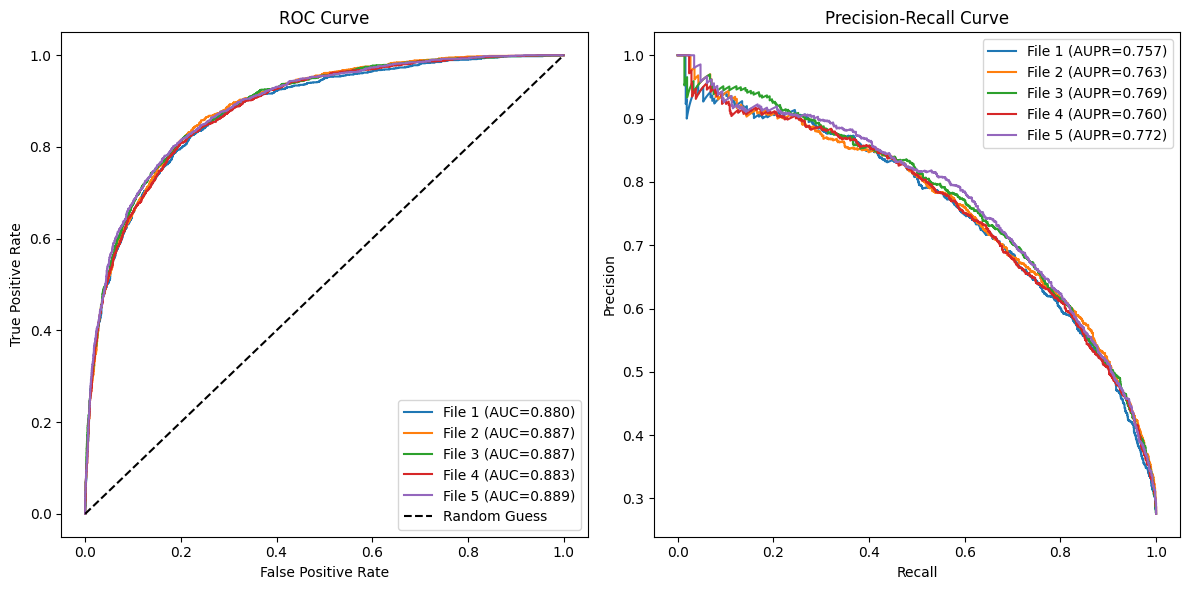

In [ ]:
# 主程序
file_paths = [
    '/ssd2/lxy_code/DTI/MFUD/result/Davis/protein_RUN_1/test_prediction_seed3.csv',
    '/ssd2/lxy_code/DTI/MFUD/result/Davis/protein_RUN_2/test_prediction_seed3.csv',
    '/ssd2/lxy_code/DTI/MFUD/result/Davis/protein_RUN_3/test_prediction_seed3.csv',
    '/ssd2/lxy_code/DTI/MFUD/result/Davis/protein_RUN_4/test_prediction_seed3.csv',
    '/ssd2/lxy_code/DTI/MFUD/result/Davis/protein_RUN_5/test_prediction_seed3.csv'
]  # 替换为实际文件路径
results = []

# 存储每次运行的指标
auc_list = []
aupr_list = []
f1_list = []
accuracy_list = []
precision_list = []
recall_list = []
mcc_list = []

for file_path in file_paths:
    result = calculate_metrics(file_path)
    results.append(result)
    
    # 提取指标
    auc_list.append(result['auc'])
    aupr_list.append(result['aupr'])
    f1_list.append(result['best_metrics']['f1'])
    accuracy_list.append(result['best_metrics']['accuracy'])
    precision_list.append(result['best_metrics']['precision'])
    recall_list.append(result['best_metrics']['recall'])
    mcc_list.append(result['best_metrics']['mcc'])
    
    # 打印每次运行的结果
    print(f"Results for {file_path}:")
    print(f"AUC: {result['auc']:.4f}, AUPR: {result['aupr']:.4f}")
    print(f"Best Threshold: {result['best_threshold']:.4f}")
    print(f"Metrics at Best Threshold: {result['best_metrics']}")
    print()

# 计算均值和标准差
metrics_summary = {
    'AUC': (np.mean(auc_list), np.std(auc_list)),
    'AUPR': (np.mean(aupr_list), np.std(aupr_list)),
    'F1': (np.mean(f1_list), np.std(f1_list)),
    'Accuracy': (np.mean(accuracy_list), np.std(accuracy_list)),
    'Precision': (np.mean(precision_list), np.std(precision_list)),
    'Recall': (np.mean(recall_list), np.std(recall_list)),
    'MCC': (np.mean(mcc_list), np.std(mcc_list))
}

# 打印均值和标准差
print("\nSummary of Metrics (Mean ± Std):")
for metric, (mean, std) in metrics_summary.items():
    print(f"{metric}: {mean:.4f} ± {std:.4f}")

# 绘制曲线
plot_curves(results, 'roc_pr_curves.png')

## scaffold

Results for /ssd2/lxy_code/DTI/MFUD/result/Davis/scaffold_RUN_1/test_prediction_seed3.csv:
AUC: 0.7258, AUPR: 0.5308
Best Threshold: 0.2132
Metrics at Best Threshold: {'accuracy': 0.6693051890941073, 'f1': 0.5316392625809666, 'precision': 0.44945240101095196, 'recall': 0.650609756097561, 'mcc': 0.3008608284679893, 'tp': 1067, 'tn': 2738, 'fp': 1307, 'fn': 573}

Results for /ssd2/lxy_code/DTI/MFUD/result/Davis/scaffold_RUN_2/test_prediction_seed3.csv:
AUC: 0.7082, AUPR: 0.5166
Best Threshold: 0.2462
Metrics at Best Threshold: {'accuracy': 0.6617414248021108, 'f1': 0.51378002528445, 'precision': 0.43887688984881207, 'recall': 0.6195121951219512, 'mcc': 0.2751396335019763, 'tp': 1016, 'tn': 2746, 'fp': 1299, 'fn': 624}

Results for /ssd2/lxy_code/DTI/MFUD/result/Davis/scaffold_RUN_3/test_prediction_seed3.csv:
AUC: 0.7252, AUPR: 0.5277
Best Threshold: 0.1261
Metrics at Best Threshold: {'accuracy': 0.6504837291116975, 'f1': 0.530814639905549, 'precision': 0.43314065510597305, 'recall': 0.68

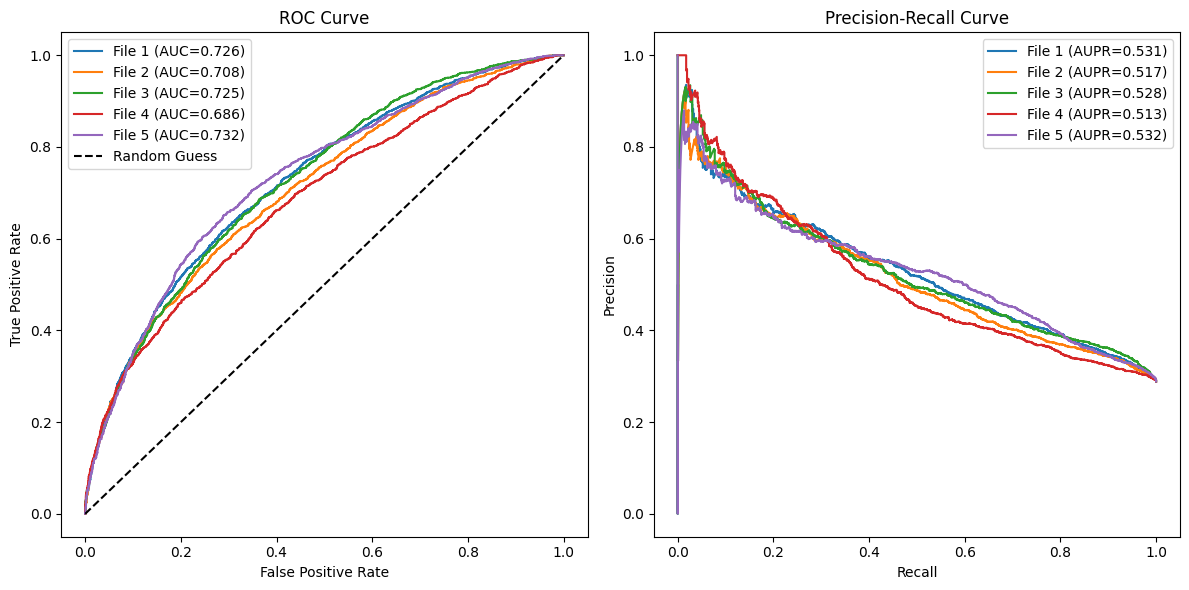

In [ ]:
# 主程序
file_paths = [
    '/ssd2/lxy_code/DTI/MFUD/result/Davis/scaffold_RUN_1/test_prediction_seed3.csv',
    '/ssd2/lxy_code/DTI/MFUD/result/Davis/scaffold_RUN_2/test_prediction_seed3.csv',
    '/ssd2/lxy_code/DTI/MFUD/result/Davis/scaffold_RUN_3/test_prediction_seed3.csv',
    '/ssd2/lxy_code/DTI/MFUD/result/Davis/scaffold_RUN_4/test_prediction_seed3.csv',
    '/ssd2/lxy_code/DTI/MFUD/result/Davis/scaffold_RUN_5/test_prediction_seed3.csv'
]  # 替换为实际文件路径
results = []

# 存储每次运行的指标
auc_list = []
aupr_list = []
f1_list = []
accuracy_list = []
precision_list = []
recall_list = []
mcc_list = []

for file_path in file_paths:
    result = calculate_metrics(file_path)
    results.append(result)
    
    # 提取指标
    auc_list.append(result['auc'])
    aupr_list.append(result['aupr'])
    f1_list.append(result['best_metrics']['f1'])
    accuracy_list.append(result['best_metrics']['accuracy'])
    precision_list.append(result['best_metrics']['precision'])
    recall_list.append(result['best_metrics']['recall'])
    mcc_list.append(result['best_metrics']['mcc'])
    
    # 打印每次运行的结果
    print(f"Results for {file_path}:")
    print(f"AUC: {result['auc']:.4f}, AUPR: {result['aupr']:.4f}")
    print(f"Best Threshold: {result['best_threshold']:.4f}")
    print(f"Metrics at Best Threshold: {result['best_metrics']}")
    print()

# 计算均值和标准差
metrics_summary = {
    'AUC': (np.mean(auc_list), np.std(auc_list)),
    'AUPR': (np.mean(aupr_list), np.std(aupr_list)),
    'F1': (np.mean(f1_list), np.std(f1_list)),
    'Accuracy': (np.mean(accuracy_list), np.std(accuracy_list)),
    'Precision': (np.mean(precision_list), np.std(precision_list)),
    'Recall': (np.mean(recall_list), np.std(recall_list)),
    'MCC': (np.mean(mcc_list), np.std(mcc_list))
}

# 打印均值和标准差
print("\nSummary of Metrics (Mean ± Std):")
for metric, (mean, std) in metrics_summary.items():
    print(f"{metric}: {mean:.4f} ± {std:.4f}")

# 绘制曲线
plot_curves(results, 'roc_pr_curves.png')

## scaffold_protein

Results for /ssd2/lxy_code/DTI/MFUD/result/Davis/scaffold_protein_RUN_1/test_prediction_seed3.csv:
AUC: 0.7299, AUPR: 0.5508
Best Threshold: 0.1461
Metrics at Best Threshold: {'accuracy': 0.6507936507936508, 'f1': 0.5567338282078473, 'precision': 0.4491017964071856, 'recall': 0.7322175732217573, 'mcc': 0.3190639184760728, 'tp': 525, 'tn': 1033, 'fp': 644, 'fn': 192}

Results for /ssd2/lxy_code/DTI/MFUD/result/Davis/scaffold_protein_RUN_2/test_prediction_seed3.csv:
AUC: 0.7208, AUPR: 0.5290
Best Threshold: 0.1041
Metrics at Best Threshold: {'accuracy': 0.6599832915622389, 'f1': 0.5642398286937901, 'precision': 0.4578627280625543, 'recall': 0.7350069735006973, 'mcc': 0.33270286874052935, 'tp': 527, 'tn': 1053, 'fp': 624, 'fn': 190}

Results for /ssd2/lxy_code/DTI/MFUD/result/Davis/scaffold_protein_RUN_3/test_prediction_seed3.csv:
AUC: 0.6973, AUPR: 0.5166
Best Threshold: 0.0671
Metrics at Best Threshold: {'accuracy': 0.6307435254803676, 'f1': 0.5195652173913043, 'precision': 0.4256455921

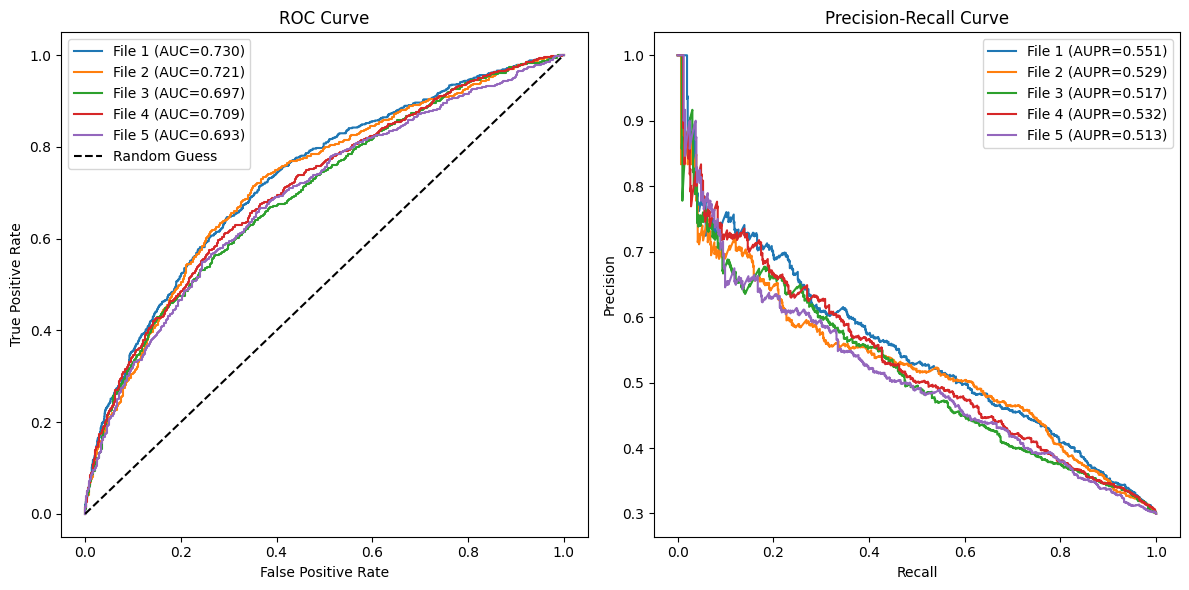

In [ ]:
# 主程序
file_paths = [
    '/ssd2/lxy_code/DTI/MFUD/result/Davis/scaffold_protein_RUN_1/test_prediction_seed3.csv',
    '/ssd2/lxy_code/DTI/MFUD/result/Davis/scaffold_protein_RUN_2/test_prediction_seed3.csv',
    '/ssd2/lxy_code/DTI/MFUD/result/Davis/scaffold_protein_RUN_3/test_prediction_seed3.csv',
    '/ssd2/lxy_code/DTI/MFUD/result/Davis/scaffold_protein_RUN_4/test_prediction_seed3.csv',
    '/ssd2/lxy_code/DTI/MFUD/result/Davis/scaffold_protein_RUN_5/test_prediction_seed3.csv'
]  # 替换为实际文件路径
results = []

# 存储每次运行的指标
auc_list = []
aupr_list = []
f1_list = []
accuracy_list = []
precision_list = []
recall_list = []
mcc_list = []

for file_path in file_paths:
    result = calculate_metrics(file_path)
    results.append(result)
    
    # 提取指标
    auc_list.append(result['auc'])
    aupr_list.append(result['aupr'])
    f1_list.append(result['best_metrics']['f1'])
    accuracy_list.append(result['best_metrics']['accuracy'])
    precision_list.append(result['best_metrics']['precision'])
    recall_list.append(result['best_metrics']['recall'])
    mcc_list.append(result['best_metrics']['mcc'])
    
    # 打印每次运行的结果
    print(f"Results for {file_path}:")
    print(f"AUC: {result['auc']:.4f}, AUPR: {result['aupr']:.4f}")
    print(f"Best Threshold: {result['best_threshold']:.4f}")
    print(f"Metrics at Best Threshold: {result['best_metrics']}")
    print()

# 计算均值和标准差
metrics_summary = {
    'AUC': (np.mean(auc_list), np.std(auc_list)),
    'AUPR': (np.mean(aupr_list), np.std(aupr_list)),
    'F1': (np.mean(f1_list), np.std(f1_list)),
    'Accuracy': (np.mean(accuracy_list), np.std(accuracy_list)),
    'Precision': (np.mean(precision_list), np.std(precision_list)),
    'Recall': (np.mean(recall_list), np.std(recall_list)),
    'MCC': (np.mean(mcc_list), np.std(mcc_list))
}

# 打印均值和标准差
print("\nSummary of Metrics (Mean ± Std):")
for metric, (mean, std) in metrics_summary.items():
    print(f"{metric}: {mean:.4f} ± {std:.4f}")

# 绘制曲线
plot_curves(results, 'roc_pr_curves.png')